<a href="https://colab.research.google.com/github/samitochi04/bookly/blob/main/Copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling
import pandas as pd

# Model selection
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save trained models
import joblib

In [ ]:
df = pd.read_csv("/content/books.csv", on_bad_lines='skip')

In [ ]:
# Separate input features and target variable
X = df.drop(columns=[
    "average_rating",
    "title",
    "authors",
    "isbn",
    "language_code",
    "publication_date",
    "publisher"
])

y = df["average_rating"]

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8898
Testing samples: 2225


In [ ]:
# Initialize and train the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Check data types of training features
X_train.dtypes

,0
bookID,int64
isbn13,int64
num_pages,int64
ratings_count,int64
text_reviews_count,int64


In [ ]:
# Display selected feature columns
print(X.columns)

Index(['bookID', 'isbn13', '  num_pages', 'ratings_count',
       'text_reviews_count'],
      dtype='object')


In [ ]:
# Select numerical features for model training
X = df.select_dtypes(include=["int64", "float64"]).drop(columns=["average_rating"])

# Define target variable
y = df["average_rating"]

In [ ]:
df.select_dtypes(include=["int64", "float64"])

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
0,1,4.57,9780439785969,652,2095690,27591
1,2,4.49,9780439358071,870,2153167,29221
2,4,4.42,9780439554893,352,6333,244
3,5,4.56,9780439655484,435,2339585,36325
4,8,4.78,9780439682589,2690,41428,164
...,...,...,...,...,...,...
11118,45631,4.06,9781560254416,512,156,20
11119,45633,4.08,9780140110876,635,783,56
11120,45634,3.96,9780140131963,415,820,95
11121,45639,3.72,9780060878825,434,769,139


In [ ]:
df.drop(columns=["average_rating"])

,bookID,title,authors,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic
...,...,...,...,...,...,...,...,...,...,...,...
11118,45631,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,1560254416,9781560254416,eng,512,156,20,12/21/2004,Da Capo Press
11119,45633,You Bright and Risen Angels,William T. Vollmann,0140110879,9780140110876,eng,635,783,56,12/1/1988,Penguin Books
11120,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,0140131965,9780140131963,eng,415,820,95,8/1/1993,Penguin Books
11121,45639,Poor People,William T. Vollmann,0060878827,9780060878825,eng,434,769,139,2/27/2007,Ecco


In [ ]:
y = df["average_rating"]

In [ ]:
# Generate predictions on the test data
y_pred = model.predict(X_test)

In [ ]:
model.predict(X_test)

array([3.923035  , 3.93732815, 3.90209224, ..., 3.92832038, 3.8748182 ,
       3.89969176])

In [ ]:
y_test

,average_rating
8661,3.85
483,3.97
8401,3.92
6380,0.00
1844,4.16
...,...
11113,3.92
2344,3.83
4099,4.00
5593,3.75


In [ ]:
y_pred

array([3.923035  , 3.93732815, 3.90209224, ..., 3.92832038, 3.8748182 ,
       3.89969176])

In [ ]:
# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.2263
Mean Squared Error (MSE): 0.1227
R-squared Score: 0.0277


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

In [ ]:
mse = mean_squared_error(y_test, y_pred)

In [ ]:
r2 = r2_score(y_test, y_pred)

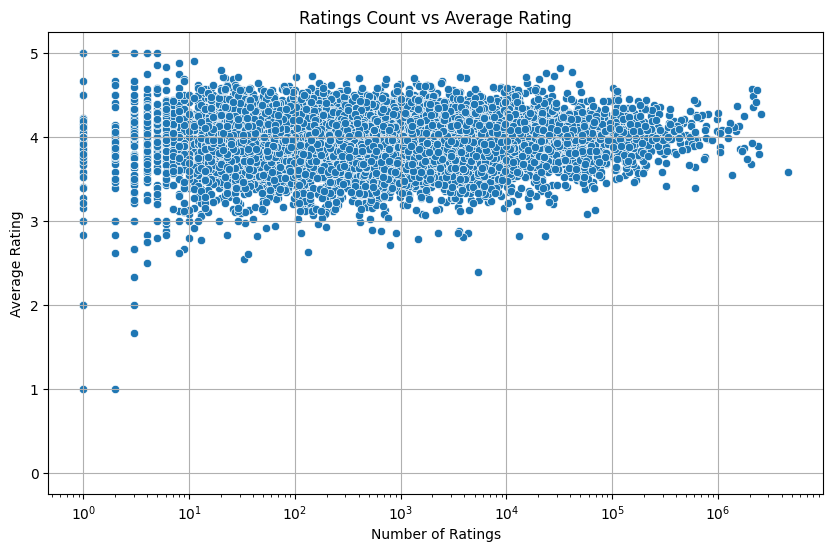

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot ratings count against average rating
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="ratings_count", y="average_rating")

plt.title("Ratings Count vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.xscale("log")
plt.grid(True)
plt.show()

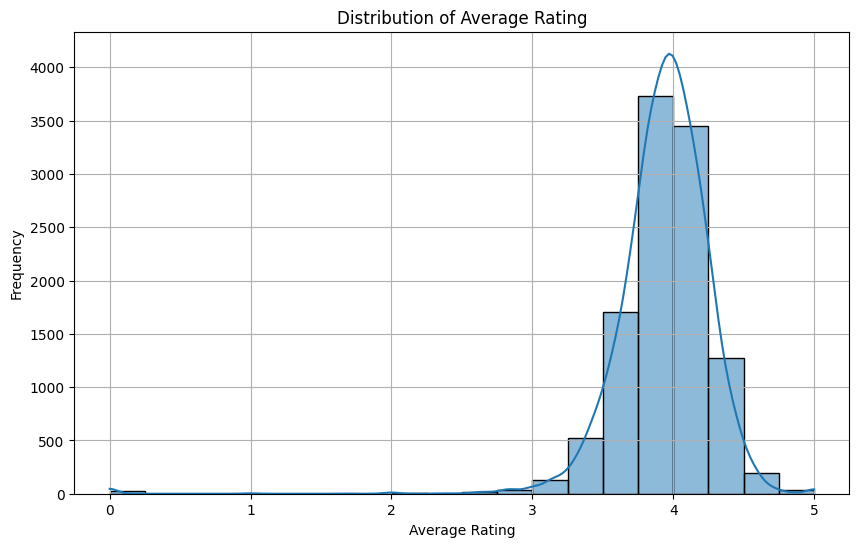

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df["average_rating"], bins=20, kde=True)

plt.title("Distribution of Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

In [ ]:
# Calculate model performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.22633594554927122
RMSE: 0.35025217536057945
R² Score: 0.027657129719910856


In [ ]:
# Train Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Make predictions
rf_pred = rf.predict(X_test)

# Check model performance
print("R² Score:", r2_score(y_test, rf_pred))

R² Score: 0.1879517731196877


In [ ]:
joblib.dump(rf, "best_model.pkl")

['best_model.pkl']